pick top w_frac fraction of edges (by Phi) to immunize (delete) and randomly rewire.

In [ ]:
#!/usr/bin/env python3
# mmca_stage_intervention.py
"""
MMCA on 3-uniform hypergraph with stage intervention:
 - Run until steady-state (or T_pre_max). Once steady, compute SIP Phi_e and
   pick top w_frac fraction of edges (by Phi) to immunize (delete) and randomly rewire.
 - Then run a post-phase of T_post steps to observe the effect on S/I.
 - Repeat this whole experiment R times (each repeat: new hypergraph).
Outputs:
 - per-run pre/post trajectories saved in out_dir
 - summary CSV with per-run steady time, pre-steady mean I, post-end mean I, #rewired
"""

import os
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import pandas as pd
from time import time

def generate_hypergraph_H_n_m_3(n, kappa, seed=None, batch_size=3000):
    if seed is not None:
        np.random.seed(seed)
        random.seed(seed)
    d = 3
    m = int(round(n * kappa / d))
    max_possible = math.comb(n, d)
    if m > max_possible:
        raise ValueError("m > C(n,3)")
    nodes = np.arange(n)
    edges_set = set()
    while len(edges_set) < m:
        tris = np.random.choice(nodes, size=(batch_size, d), replace=True)
        for i in range(tris.shape[0]):
            row = tris[i]
            if len(np.unique(row)) < d:
                row = np.random.choice(nodes, size=(d,), replace=False)
            tris[i] = np.sort(row)
        for row in tris:
            if len(edges_set) >= m:
                break
            edges_set.add(tuple(row.tolist()))
    hyperedges = np.array(list(edges_set), dtype=int)
    hyperedges.sort(axis=1)
    return hyperedges

class HyperSISModel:
    def __init__(self, hyperedges, n):
        self.hyperedges = np.asarray(hyperedges, dtype=int)
        self.n = n
        self.m = self.hyperedges.shape[0]
        self.edge_i = self.hyperedges[:,0].copy()
        self.edge_j = self.hyperedges[:,1].copy()
        self.edge_k = self.hyperedges[:,2].copy()
        self._build_node_incidence()

    def _build_node_incidence(self):
        self.node_edge_pos = [[] for _ in range(self.n)]
        for ei in range(self.m):
            a,b,c = self.hyperedges[ei]
            self.node_edge_pos[a].append((ei,0))
            self.node_edge_pos[b].append((ei,1))
            self.node_edge_pos[c].append((ei,2))

    def _compute_edge_products(self, p):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        return (p_j * p_k, p_i * p_k, p_i * p_j)

    def _update_theta_from_p(self, p, Theta, eta, gamma):
        p_i = p[self.edge_i]; p_j = p[self.edge_j]; p_k = p[self.edge_k]
        Phi = p_i * p_j * p_k
        Theta_new = Theta * (1.0 - eta * Phi) + gamma * (1.0 - Theta)
        Theta_new = np.clip(Theta_new, 0.0, 1.0)
        return Theta_new, Phi

    def _random_new_edge(self, existing_set, rng, d=3, max_tries=500):
        tries = 0
        while tries < max_tries:
            nodes = rng.choice(self.n, size=(d,), replace=False)
            nodes.sort()
            tup = tuple(int(x) for x in nodes.tolist())
            if tup not in existing_set:
                return np.array(nodes, dtype=int)
            tries += 1
        nodes = rng.choice(self.n, size=(d,), replace=False)
        nodes.sort()
        return np.array(nodes, dtype=int)

    def run_mmca_stage_intervention(self,
                                    beta_d=0.3, mu=0.2, eta=1.0, gamma=0.05,
                                    T_pre_max=200, T_post=100, init_frac=0.01,
                                    w_frac=0.1,  # fraction of edges to immunize at stage
                                    seed=None, verbose=False):
        """
        # 阶段1：监测期（Pre-phase）
        - 运行直到系统达到稳态
        - 监测超边的感染压力(Φ)
        - 识别高风险超边

        # 阶段2：干预期（Post-phase）  
        - 执行针对性免疫
        - 观察干预效果
        - 无进一步主动干预
        Stage intervention workflow (modified):
        - run pre-phase for exactly T_pre_max steps (steady determined by reaching T_pre_max)
        - compute Phi_e (SIP) at that time, choose top w_frac fraction edges by Phi
        - delete those edges and random-rewire same number (Theta_new=1)
        - run post-phase T_post steps and return full trajectories

        Returns:
        pre_rho_ts (length T_pre_max+1), pre_theta_mean_ts (length T_pre_max+1),
        post_rho_ts (length T_post+1), post_theta_mean_ts (length T_post+1),
        info dict { 't_ss': t_ss, 'num_rewired': num_rewired,
                    'pre_ss_rho_mean': ..., 'post_end_rho_mean': ... }

        Note: this will modify self.hyperedges in-place for the post-phase.
        """
        # RNG
        rng = np.random.default_rng(seed) if seed is not None else np.random

        # init
        p = np.full(self.n, init_frac, dtype=float)
        # 初始超边活跃度为 0.6
        Theta = np.ones(self.m, dtype=float)*1.0
        edge_set = set(tuple(row.tolist()) for row in self.hyperedges)

        pre_rho = []
        pre_theta_mean = []

        # pre-phase: 运行 T_pre_max 时间步
        for t in range(T_pre_max):
            pre_rho.append(p.mean())
            pre_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            # 计算每一个节点的 Q
            Q = np.zeros(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)

            p = p_next

            if verbose and (t % 50 == 0):
                print(f"[pre t={t}] rho={pre_rho[-1]:.6f}  meanTheta={pre_theta_mean[-1]:.6f}")

        # set steady time to last pre-step 
        t_ss = T_pre_max - 1

        # pre-steady summary: use last pre-step value (no window averaging)
        pre_ss_rho_mean = float(pre_rho[-1])

        # --- 阶段干预：选取top-w_frac超边，在‘steady’计算Phi值 ---
        p_for_phi = p.copy()
        Phi_e = (p_for_phi[self.edge_i] * p_for_phi[self.edge_j] * p_for_phi[self.edge_k])
        sorted_idx = np.argsort(-Phi_e) # 实现了对原数组的降序排序

        # 计算要干预的超边数量
        num_rewire = max(1, int(np.ceil(w_frac * self.m))) if w_frac > 0 else 0
        # 选取感染压力最大的前 num_rewire 条超边
        top_idx = sorted_idx[:num_rewire]

        # 免疫top感染压力超边并重连 (random rewire) 
        if num_rewire > 0:
            for ei in top_idx:
                tup = tuple(int(x) for x in self.hyperedges[ei].tolist())
                if tup in edge_set:
                    edge_set.remove(tup)
                self.hyperedges[ei] = np.array([-1,-1,-1], dtype=int)
                Theta[ei] = 0.0

            for ei in top_idx:
                new_edge = self._random_new_edge(existing_set=edge_set, rng=rng, d=3, max_tries=2000)
                new_tup = tuple(int(x) for x in new_edge.tolist())
                self.hyperedges[ei] = new_edge
                self.edge_i[ei], self.edge_j[ei], self.edge_k[ei] = new_edge
                edge_set.add(new_tup)
                Theta[ei] = 0.1
                # 或者在0.3-0.6之间随机选择
                # Theta[ei] = np.random.uniform(0.3, 0.6)

            self._build_node_incidence()

        # post-phase：运行T_post步骤 (no further external interventions)
        post_rho = []
        post_theta_mean = []
        for t in range(T_post):
            post_rho.append(p.mean())
            post_theta_mean.append(Theta.mean())

            prod_pos0, prod_pos1, prod_pos2 = self._compute_edge_products(p)

            Q = np.zeros(self.n, dtype=float)
            for node in range(self.n):
                prod_val = 1.0
                for (ei,pos) in self.node_edge_pos[node]:
                    if pos == 0:
                        prod_oth = prod_pos0[ei]
                    elif pos == 1:
                        prod_oth = prod_pos1[ei]
                    else:
                        prod_oth = prod_pos2[ei]
                    prod_val *= (1.0 - Theta[ei] * beta_d * prod_oth)
                Q[node] = prod_val

            p_next = (1.0 - p) * (1.0 - Q) + (1.0 - mu) * p
            Theta, Phi = self._update_theta_from_p(p, Theta, eta, gamma)
            p = p_next

        # append final step stats
        post_rho.append(p.mean())
        post_theta_mean.append(Theta.mean())

        # post-end summary: use last post-step value
        post_end_rho = float(post_rho[-1])

        info = {
            't_ss': int(t_ss),
            'num_rewired': int(num_rewire),
            'pre_ss_rho_mean': float(pre_ss_rho_mean),
            'post_end_rho_mean': float(post_end_rho)
        }

        return np.array(pre_rho), np.array(pre_theta_mean), np.array(post_rho), np.array(post_theta_mean), info


# -------------------- Parameters (example) --------------------
n = 1000
kappa = 6.0
beta = 0.3
mu = 0.1
T_pre_max = 500      # max steps to wait for steady
T_post = 200         # steps after intervention to observe effect
init_frac = 0.1
seed = 12345
eta = 0.8
gamma = 0.015

w_frac = 0.5    # 免疫超边比例
R = 5           # 重复实验

out_dir = "stage_intervention_runs"
os.makedirs(out_dir, exist_ok=True)
# # save pre/post trajectories for this run (pre: time 0..t_ss, post: 0..T_post)
#     fn_pre = os.path.join(out_dir, f"run{r:03d}_pre_rho.csv")
#     fn_post = os.path.join(out_dir, f"run{r:03d}_post_rho.csv")
#     pd.DataFrame({'rho': pre_rho}).to_csv(fn_pre, index=False)
#     pd.DataFrame({'rho': post_rho}).to_csv(fn_post, index=False)

# Storage
summary_rows = []
t0_all = time()
# 用于汇总所有重复实验的结果
all_pre_rho = []
all_post_rho = []

for r in range(R):
    gen_seed = None if seed is None else (seed + r)
    run_seed = None if seed is None else (seed + 1000 + r)

    # 生成初始超图
    hyperedges = generate_hypergraph_H_n_m_3(
        n=n, kappa=kappa, seed=gen_seed, batch_size=3000
    )
    model = HyperSISModel(hyperedges, n)

    # 运行 MMCA 模型（分为干预前和干预后阶段）
    pre_rho, pre_theta_mean, post_rho, post_theta_mean, info = model.run_mmca_stage_intervention(
        beta_d=beta, mu=mu, eta=eta, gamma=gamma,
        T_pre_max=T_pre_max, T_post=T_post,
        init_frac=init_frac, w_frac=w_frac,
        seed=run_seed, verbose=True
    )

    # 收集所有实验的 pre/post 感染率序列
    all_pre_rho.append(pre_rho)
    all_post_rho.append(post_rho)

    # 记录汇总信息
    summary_rows.append({
        'run': r,
        't_ss': info['t_ss'],
        'num_rewired': info['num_rewired'],
        'pre_ss_rho_mean': info['pre_ss_rho_mean'],
        'post_end_rho_mean': info['post_end_rho_mean']
    })

    if (r + 1) % 5 == 0 or (r + 1) == R:
        print(f"已完成 {r + 1}/{R} 次实验，用时 {(time() - t0_all):.1f} 秒")

# -------------------- 保存所有实验结果 --------------------
# 合并为 DataFrame，列为不同实验
df_pre = pd.DataFrame(all_pre_rho).T  # shape: [T_pre_max+1, R]
df_post = pd.DataFrame(all_post_rho).T  # shape: [T_post+1, R]

# 保存为整体 CSV
df_pre.to_csv(os.path.join(out_dir, "pre_rho_all.csv"), index=False, header=False)
df_post.to_csv(os.path.join(out_dir, "post_rho_all.csv"), index=False, header=False)

# 保存汇总统计结果
df_summary = pd.DataFrame(summary_rows)
df_summary.to_csv(os.path.join(out_dir, "summary_stage_intervention.csv"), index=False)

print("✅ 已保存以下结果：")
print(" - pre_rho_all.csv  （所有实验的干预前感染率）")
print(" - post_rho_all.csv （所有实验的干预后感染率）")
print(" - summary_stage_intervention.csv （每次实验统计信息）")
print("总运行时间: {:.1f} 秒".format(time() - t0_all))


[pre t=0] rho=0.100000  meanTheta=1.000000
[pre t=50] rho=0.167924  meanTheta=0.295294
[pre t=100] rho=0.358964  meanTheta=0.159970
[pre t=150] rho=0.431885  meanTheta=0.208147
[pre t=200] rho=0.374550  meanTheta=0.248850
[pre t=250] rho=0.346932  meanTheta=0.243794
[pre t=300] rho=0.347334  meanTheta=0.232359
[pre t=350] rho=0.354941  meanTheta=0.226838
[pre t=400] rho=0.359458  meanTheta=0.226783
[pre t=450] rho=0.359838  meanTheta=0.228348
[pre t=0] rho=0.100000  meanTheta=1.000000
[pre t=50] rho=0.167922  meanTheta=0.295318
[pre t=100] rho=0.363954  meanTheta=0.159514
[pre t=150] rho=0.433247  meanTheta=0.212670
[pre t=200] rho=0.371749  meanTheta=0.251905
[pre t=250] rho=0.345631  meanTheta=0.244607
[pre t=300] rho=0.347916  meanTheta=0.232516
[pre t=350] rho=0.356320  meanTheta=0.227382
[pre t=400] rho=0.360577  meanTheta=0.227891
[pre t=450] rho=0.360462  meanTheta=0.229655
[pre t=0] rho=0.100000  meanTheta=1.000000
[pre t=50] rho=0.168737  meanTheta=0.295399
[pre t=100] rho=0.3

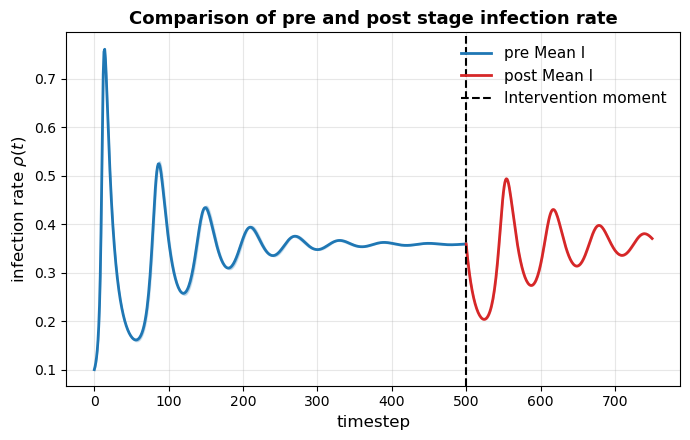

------ 干预阶段统计 ------
实验次数 R = 5
干预前稳态平均感染率: 0.3590
干预后末态平均感染率: 0.3703
平均重连超边数: 1000.0


In [16]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ==================== 读取 CSV 数据 ====================
out_dir = "./stage_intervention_runs"  # 替换为你的输出路径
pre_file = os.path.join(out_dir, "pre_rho_all.csv")
post_file = os.path.join(out_dir, "post_rho_all.csv")
summary_file = os.path.join(out_dir, "summary_stage_intervention.csv")

# 读取感染率时间序列（每一列对应一次实验）
pre_rho_all = pd.read_csv(pre_file, header=None).to_numpy()   # shape: (T_pre, R)
post_rho_all = pd.read_csv(post_file, header=None).to_numpy() # shape: (T_post, R)

# 读取汇总信息
df_summary = pd.read_csv(summary_file)
R = pre_rho_all.shape[1]
T_pre = pre_rho_all.shape[0]
T_post = post_rho_all.shape[0]

# ==================== 计算均值与标准差 ====================
mean_pre = pre_rho_all.mean(axis=1)
std_pre = pre_rho_all.std(axis=1)

mean_post = post_rho_all.mean(axis=1)
std_post = post_rho_all.std(axis=1)

# 拼接时间轴（post 段时间从 T_pre 开始）
t_pre = np.arange(T_pre)
t_post = np.arange(T_post) + T_pre

# ==================== 绘制对比图 ====================
plt.figure(figsize=(7, 4.5))

# --- 干预前阶段 ---
plt.plot(t_pre, mean_pre, color='#1f77b4', lw=2, label='pre Mean I')
plt.fill_between(t_pre, mean_pre - std_pre, mean_pre + std_pre,
                 color='#1f77b4', alpha=0.2)

# --- 干预后阶段 ---
plt.plot(t_post, mean_post, color='#d62728', lw=2, label='post Mean I')
plt.fill_between(t_post, mean_post - std_post, mean_post + std_post,
                 color='#d62728', alpha=0.2)

# --- 干预点 ---
plt.axvline(T_pre, color='k', linestyle='--', lw=1.5, label='Intervention moment')

# --- 图形美化 ---
plt.xlabel("timestep", fontsize=12)
plt.ylabel("infection rate $\\rho(t)$", fontsize=12)
plt.title("Comparison of pre and post stage infection rate", fontsize=13, fontweight='bold')
plt.legend(frameon=False, fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

# 保存或显示
# plt.savefig(os.path.join(out_dir, "compare_pre_post_rho.png"), dpi=300)
plt.show()

# ==================== 可选：打印统计信息 ====================
print("------ 干预阶段统计 ------")
print(f"实验次数 R = {R}")
print(f"干预前稳态平均感染率: {df_summary['pre_ss_rho_mean'].mean():.4f}")
print(f"干预后末态平均感染率: {df_summary['post_end_rho_mean'].mean():.4f}")
print(f"平均重连超边数: {df_summary['num_rewired'].mean():.1f}")
